# 01 — Who Invests? Determinants of Securities Market Participation

SEBI Household Survey 2015. Urban India.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA   = Path("..") / "data"
SEBI   = DATA / "sebi"

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## 1. Education × Participation

   education_level years_schooling  pct_who_invest
      Not Literate               0             0.5
           Primary             1-7             1.3
         Secondary            8-10             5.7
  Higher Secondary           11-15            15.4
Graduate and Above             >15            24.9


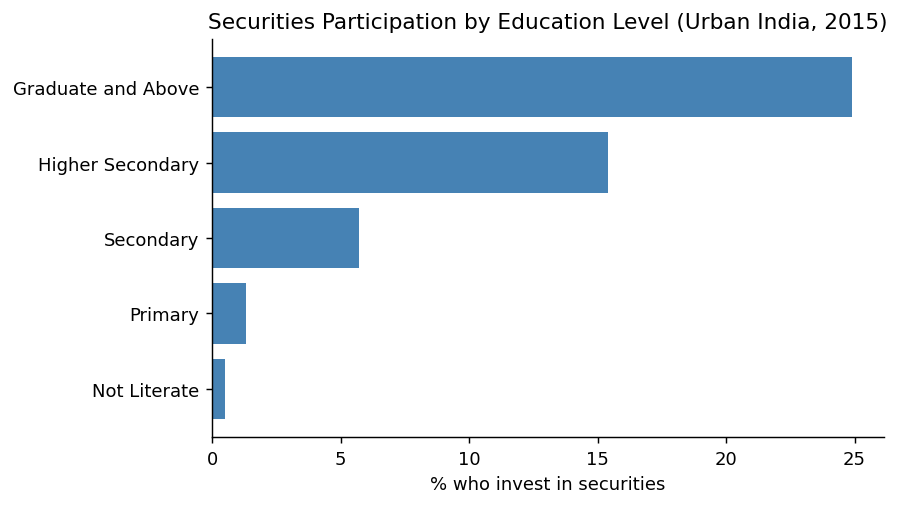

In [2]:
edu_part = pd.read_csv(SEBI / "education_participation.csv")
print(edu_part.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(edu_part["education_level"], edu_part["pct_who_invest"], color="steelblue")
ax.set_xlabel("% who invest in securities")
ax.set_title("Securities Participation by Education Level (Urban India, 2015)")
plt.tight_layout()
plt.show()


## 2. Education × Instrument Choice

   education_level years_schooling  mf_pct  equity_pct  debt_pct  n_investors
           Primary             1-7    68.8        28.1       0.0           32
         Secondary            8-10    61.3        24.3      20.2          445
  Higher Secondary           11-15    55.9        49.7      20.2         2324
Graduate and Above             >15    76.0        65.3      27.3         2551


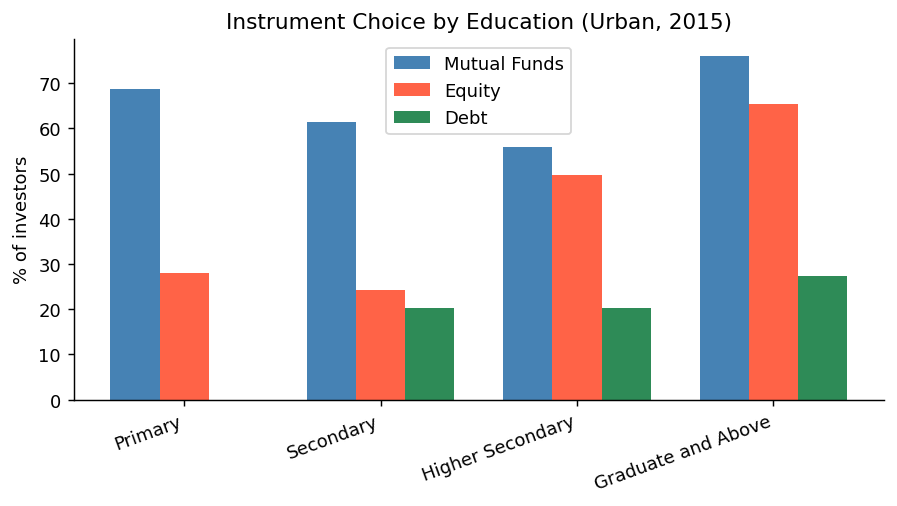

In [3]:
edu_inst = pd.read_csv(SEBI / "education_instrument_choice.csv")
print(edu_inst.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(edu_inst))
w = 0.25
ax.bar([i - w for i in x], edu_inst["mf_pct"],    w, label="Mutual Funds", color="steelblue")
ax.bar([i     for i in x], edu_inst["equity_pct"], w, label="Equity",       color="tomato")
ax.bar([i + w for i in x], edu_inst["debt_pct"],   w, label="Debt",         color="seagreen")
ax.set_xticks(list(x))
ax.set_xticklabels(edu_inst["education_level"], rotation=20, ha="right")
ax.set_ylabel("% of investors")
ax.set_title("Instrument Choice by Education (Urban, 2015)")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Income × Instrument Choice (File 05)

investor_type     Debt Investor  Equity Investor  Mutual Fund Investor  \
income_range                                                             
20,000 to 50,000            732             1626                  2161   
50,000 to 1 lakh             54              336                   195   
Above 1 lakh                159              314                   451   
Less than 20,000            311              665                   729   

investor_type     Total Investors  Total Respondents  
income_range                                          
20,000 to 50,000             3236              13403  
50,000 to 1 lakh              478               3721  
Above 1 lakh                  609               6944  
Less than 20,000             1033              12688  


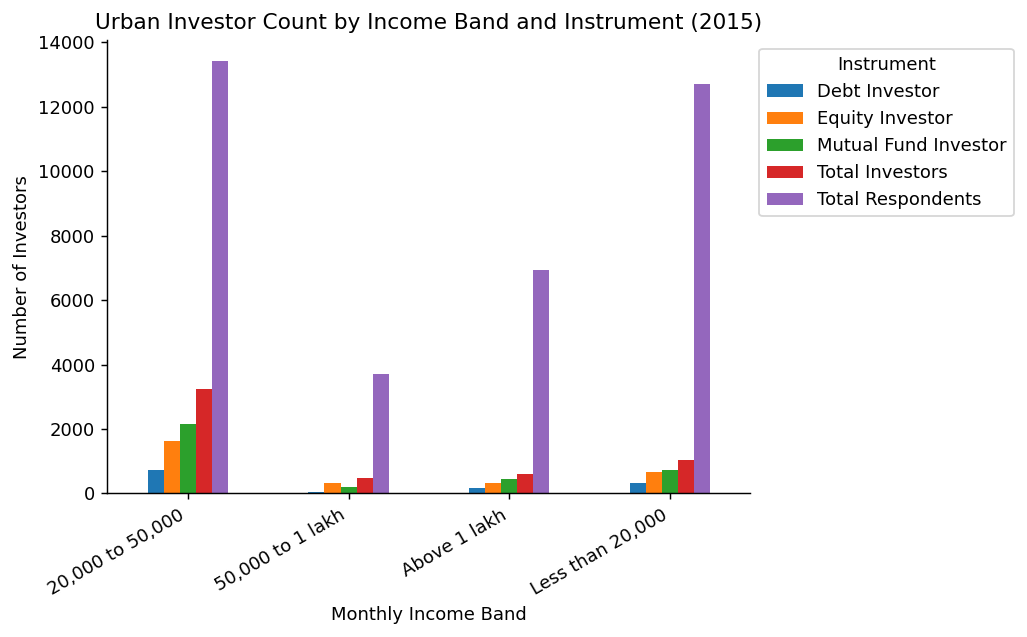

In [4]:
inc = pd.read_csv(SEBI / "05_urban_investment_instrument_choice_by_income.csv")
inc.columns = ["country", "year", "investor_type", "range", "income_range", "n_investors", "pct_of_total"]

pivot = inc.pivot_table(index="income_range", columns="investor_type", values="n_investors", aggfunc="sum")
print(pivot)

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_xlabel("Monthly Income Band")
ax.set_ylabel("Number of Investors")
ax.set_title("Urban Investor Count by Income Band and Instrument (2015)")
ax.legend(title="Instrument", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Occupation × Participation (File 14)

             occupation  pct_non_investor  pct_investor
          Self Employed              96.8           3.2
     Others ( Specify )              96.4           3.7
            Agriculture              95.7           4.3
                Retired              91.5           8.5
    Service ( Private )              89.4          10.6
                  Total              85.4          14.6
         Other Business              83.7          16.3
Business ( Shop Owner )              80.7          19.3
 Service ( Government )              76.9          23.1


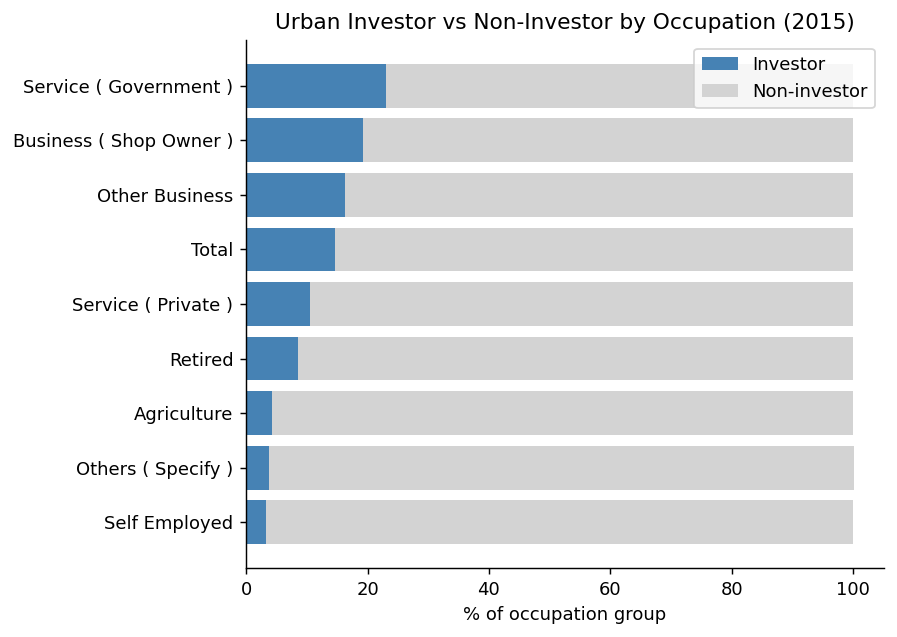

In [5]:
occ = pd.read_csv(SEBI / "14_urban_investors_by_occupation.csv")
occ.columns = ["country", "year", "occupation", "pct_non_investor", "pct_investor"]
occ = occ.sort_values("pct_investor", ascending=True)
print(occ[["occupation", "pct_non_investor", "pct_investor"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(occ["occupation"], occ["pct_investor"], color="steelblue", label="Investor")
ax.barh(occ["occupation"], occ["pct_non_investor"], left=occ["pct_investor"], color="lightgrey", label="Non-investor")
ax.set_xlabel("% of occupation group")
ax.set_title("Urban Investor vs Non-Investor by Occupation (2015)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Savings by Income (File 04)

savings_bucket  40 Percentage - 60 Percentage of annual income  \
income_band                                                      
20000-50000                                               3660   
50000-1 Lakh                                               624   
Above 1 Lakh                                               843   
Below 20000                                               1506   

savings_bucket  < 40 Percentage of annual income  \
income_band                                        
20000-50000                                 8833   
50000-1 Lakh                                2920   
Above 1 Lakh                                5513   
Below 20000                                10569   

savings_bucket  > 60 Percentage of annual income  
income_band                                       
20000-50000                                  771  
50000-1 Lakh                                 143  
Above 1 Lakh                                 569  
Below 20000                        

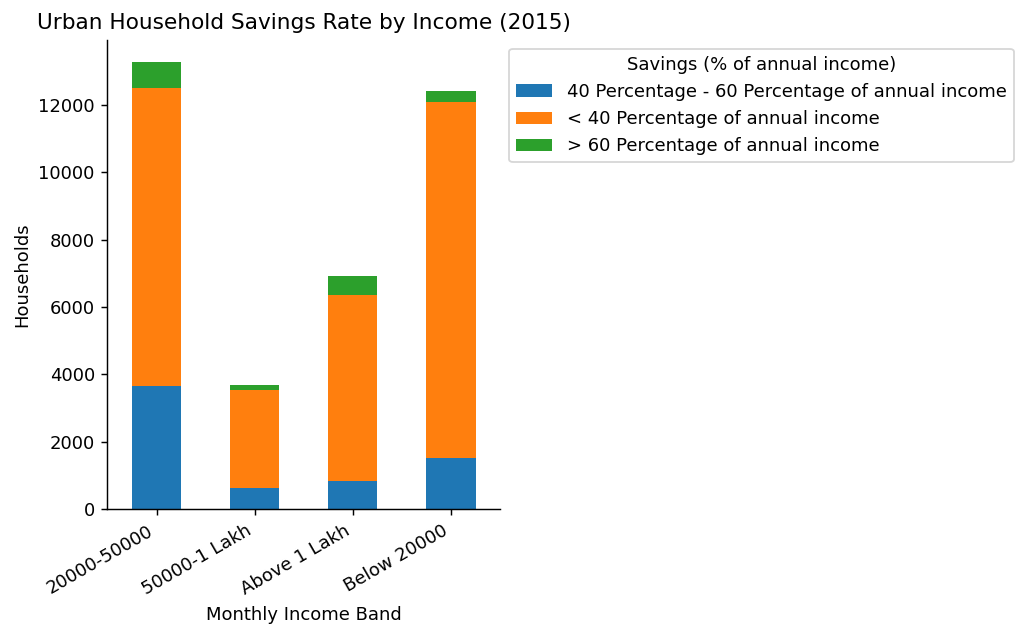

In [6]:
sav = pd.read_csv(SEBI / "04_total_savings_urban_household_pct_annual_income.csv")
sav.columns = ["country", "year", "savings_bucket", "income_band", "n_households"]

pivot_s = sav.pivot_table(index="income_band", columns="savings_bucket", values="n_households", aggfunc="sum")
print(pivot_s)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_s.plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("Monthly Income Band")
ax.set_ylabel("Households")
ax.set_title("Urban Household Savings Rate by Income (2015)")
ax.legend(title="Savings (% of annual income)", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Debt by Income (File 12)

debt_bucket            40 % -60 % of annual income  < 40 % of annual income  \
income_band                                                                   
Above 1 Lakh                                   894                     5619   
Below Rs. 20000                               3733                     4892   
Rs. 20000 - Rs. 50000                         3993                     7580   
Rs. 50000 - 1 Lakh                             605                     2751   

debt_bucket            > 60 % of annual income  
income_band                                     
Above 1 Lakh                               412  
Below Rs. 20000                           3791  
Rs. 20000 - Rs. 50000                     1691  
Rs. 50000 - 1 Lakh                         331  


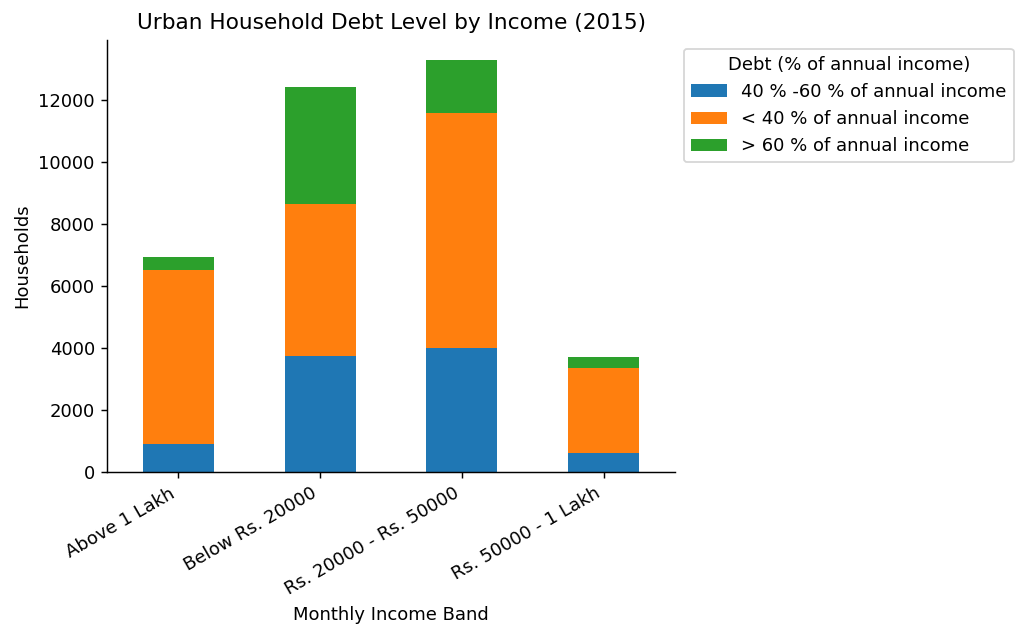

In [7]:
debt = pd.read_csv(SEBI / "12_total_urban_debt_pct_annual_income_by_income_band.csv")
debt.columns = ["country", "year", "income_band", "debt_bucket", "n_households"]

pivot_d = debt.pivot_table(index="income_band", columns="debt_bucket", values="n_households", aggfunc="sum")
print(pivot_d)

fig, ax = plt.subplots(figsize=(8, 5))
pivot_d.plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("Monthly Income Band")
ax.set_ylabel("Households")
ax.set_title("Urban Household Debt Level by Income (2015)")
ax.legend(title="Debt (% of annual income)", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
